## Data Preparation and Data Cleaning

This section includes loading the dataset, handling missing values, and detecting outliers.

### Get the data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

In [2]:
# Download the Dataset
import os

def download_dataset():
    # Kaggle CLI command to download the "Credit Card Fraud Detection" dataset
    kaggle_command = "kaggle datasets download -d mlg-ulb/creditcardfraud -p ../data/"
    unzip_command = "unzip -o ../data/creditcardfraud.zip -d ../data/"
    # Check if the dataset already exists to avoid re-downloading
    if not os.path.exists("../data/creditcard.csv"):
        # Execute shell commands
        os.system(kaggle_command)
        os.system(unzip_command)

# Ensure the dataset is downloaded
download_dataset()

In [3]:
# Load the dataset
data = pd.read_csv("../data/creditcard.csv")

### Display basic information

In [4]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### Detect missing values and outliers

In [7]:
# Detect outliers using a threshold of [-5, 5]
import numpy as np

# Count values outside the range [-5, 5]
outlier_counts = {}
for column in data.columns[:-1]:  # Exclude the target column
    outlier_counts[column] = ((data[column] > 5) | (data[column] < -5)).sum()

print("Outlier counts for values outside [-5, 5]:")
print(outlier_counts)

Outlier counts for values outside [-5, 5]:
{'Time': np.int64(284800), 'V1': np.int64(5187), 'V2': np.int64(4229), 'V3': np.int64(1594), 'V4': np.int64(765), 'V5': np.int64(1887), 'V6': np.int64(1177), 'V7': np.int64(1867), 'V8': np.int64(2577), 'V9': np.int64(677), 'V10': np.int64(1730), 'V11': np.int64(163), 'V12': np.int64(321), 'V13': np.int64(2), 'V14': np.int64(639), 'V15': np.int64(8), 'V16': np.int64(232), 'V17': np.int64(459), 'V18': np.int64(94), 'V19': np.int64(6), 'V20': np.int64(891), 'V21': np.int64(1033), 'V22': np.int64(71), 'V23': np.int64(581), 'V24': np.int64(0), 'V25': np.int64(19), 'V26': np.int64(0), 'V27': np.int64(178), 'V28': np.int64(121), 'Amount': np.int64(215775)}


In [8]:
# Cap values within the range [-5, 5]
data_clipped = data.copy()
data_clipped.iloc[:, :-1] = data_clipped.iloc[:, :-1].apply(lambda x: np.clip(x, -5, 5))

In [9]:
# Apply log transformation to the Amount column
data_clipped['Amount'] = np.log1p(data_clipped['Amount'])  # log1p handles log(0) safely

print("Log-transformed 'Amount' column:")
print(data_clipped['Amount'].describe())

Log-transformed 'Amount' column:
count    284807.000000
mean          1.593826
std           0.410998
min           0.000000
25%           1.791759
50%           1.791759
75%           1.791759
max           1.791759
Name: Amount, dtype: float64


## EDA and Feature Importance Analysis

This section explores the dataset, analyzes class imbalance, and evaluates feature importance using mutual information, logistic regression coefficients, and tree-based methods.

### Check target class imbalance

In [10]:
class_counts = data['Class'].value_counts()
class_counts

Class
0    284315
1       492
Name: count, dtype: int64

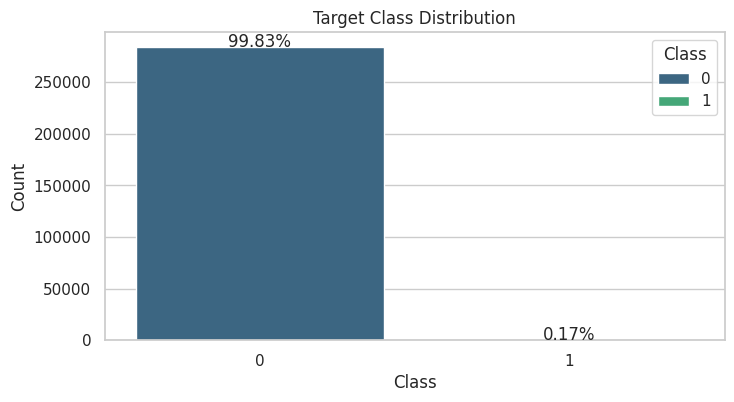

In [11]:
# Target class distribution plot
plt.figure(figsize=(8, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette="viridis", dodge=False)
for i, value in enumerate(class_counts.values):
    plt.text(i, value + 100, f'{(value / class_counts.sum() * 100):.2f}%', ha='center')
plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

### Check Time feature and correlation matrix

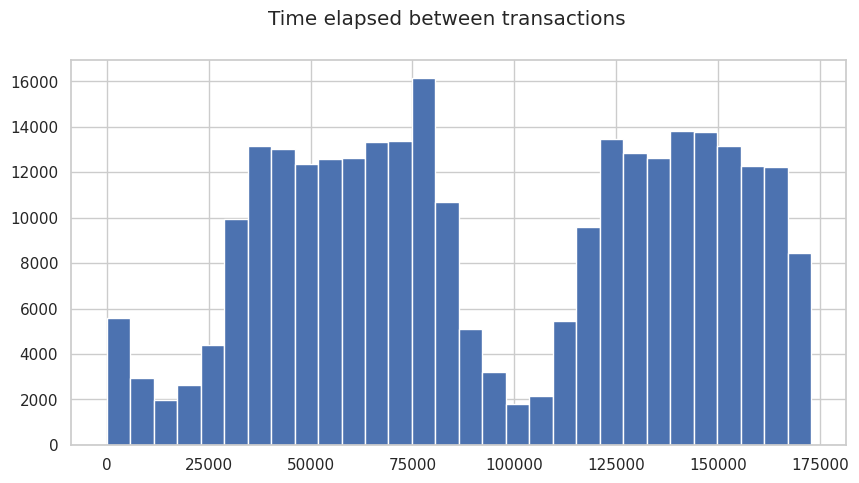

In [12]:
# Check Time feature plot (the time elapsed between transactions) 
data.Time.hist(bins=30, figsize=(10, 5))
plt.suptitle("Time elapsed between transactions")
plt.show()

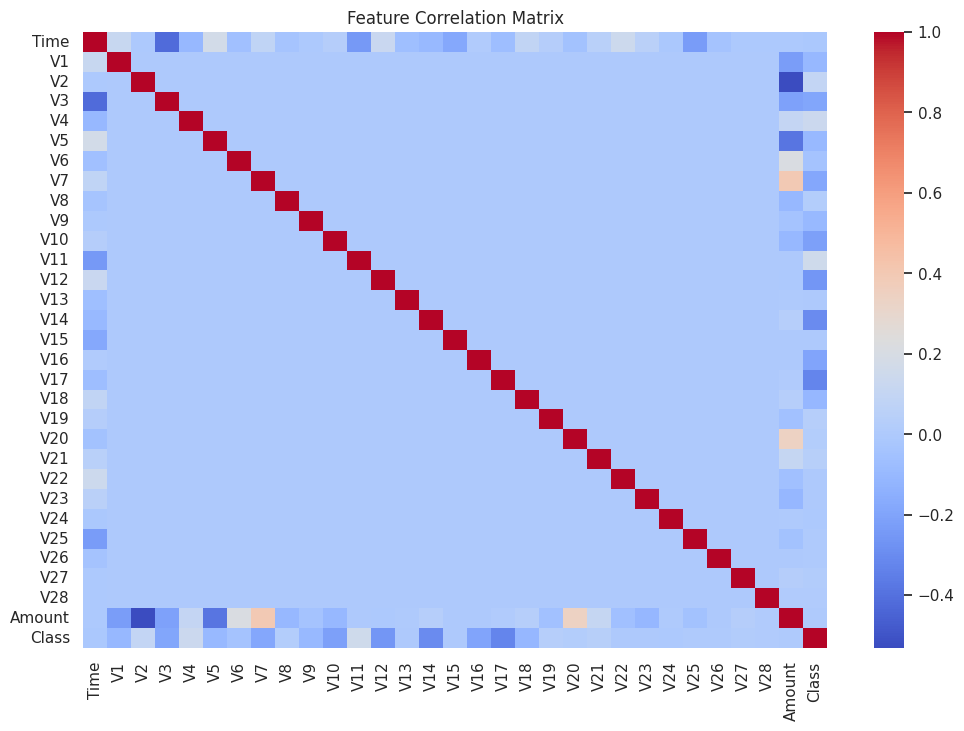

In [13]:
# Feature correlation matrix
correlation_matrix = data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", fmt='.2f')
plt.title("Feature Correlation Matrix")
plt.show()

### Feature importance methods

In [14]:
# Analyze feature importance using mutual information
from sklearn.feature_selection import mutual_info_classif #, mutual_info_score

X = data.drop(columns=['Class'])
y = data['Class']
mutual_info = mutual_info_classif(X, y)
# Indexing the mutual_info array with pd.Series
mutual_info_series = pd.Series(mutual_info, index=X.columns).sort_values(ascending=False)
print("Top 5 Features by mutual information:")
print(mutual_info_series.head())

Top 5 Features by mutual information:
V17    0.008258
V14    0.008136
V12    0.007601
V10    0.007530
V11    0.006831
dtype: float64


In [15]:
# Analyze feature importance using logistic regression coefficients
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Split the data into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Train a Logistic Regression model
model = LogisticRegression(random_state=42, max_iter=2000)
model.fit(X_train_scaled, y_train)
#model.fit(X_train, y_train)

# Get feature importance from coefficients using the validation set
val_feature_importance = pd.Series(model.coef_[0], index=X.columns).sort_values(ascending=False)
print("Feature Importance based on Logistic Regression (Validation Set):")
print(val_feature_importance.head())

Feature Importance based on Logistic Regression (Validation Set):
V4        0.811116
V22       0.427484
V21       0.271740
Amount    0.141431
V5        0.123022
dtype: float64


In [16]:
# Analyze feature importance using tree-based feature importance
from sklearn.ensemble import RandomForestClassifier

# Train a Random Forest model with max_depth to prevent overfitting
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# Get feature importance from the Random Forest model
rf_feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Feature Importance based on Random Forest:")
print(rf_feature_importance.head())

Feature Importance based on Random Forest:
V17    0.178367
V12    0.151116
V14    0.141666
V10    0.081707
V16    0.080573
dtype: float64


### Feature Importance Analysis

Feature importance using three different methods:

1. **Mutual Information**:
   - This method measures the dependency between each feature and the target variable.
   - Top 5 features by mutual information:
     - V17, V14, V12, V10, V16

2. **Logistic Regression Coefficients**:
   - This method identifies features that have the most influence on the model's predictions.
   - Results with `max_iter=2000` and scaling:
     - Top 5 features: V4, V22, V21, Amount, V5
   - Scaling was necessary to ensure convergence and reliable results.

3. **Tree-Based Feature Importance (Random Forest)**:
   - This method evaluates the importance of features based on their contribution to reducing impurity in decision trees.
   - Top 5 features:
     - V17, V12, V14, V10, V16

### Observations:
- Features `V17`, `V14`, and `V12` consistently appear as important across multiple methods.
- The `Amount` feature is highlighted by Logistic Regression after scaling, indicating its relevance when properly normalized.
- Tree-based methods and mutual information emphasize `V17` and `V14`, suggesting their strong predictive power.

In [17]:
# Summarize feature importance results
feature_importance_summary = {
    "Mutual Information": ["V17", "V14", "V12", "V10", "V16"],
    "Logistic Regression (scaled)": ["V4", "V22", "V21", "Amount", "V5"],
    "Random Forest": ["V17", "V12", "V14", "V10", "V16"]
}
import pandas as pd
importance_df = pd.DataFrame.from_dict(feature_importance_summary, orient="index").transpose()
importance_df.columns = ["Mutual Information", "Logistic Regression (scaled)", "Random Forest"]
print("Feature Importance Summary:")
print(importance_df)

Feature Importance Summary:
  Mutual Information Logistic Regression (scaled) Random Forest
0                V17                           V4           V17
1                V14                          V22           V12
2                V12                          V21           V14
3                V10                       Amount           V10
4                V16                           V5           V16


## Model Selection Process and Parameter Tuning

This section will include training different models, performing cross-validation, and tuning hyperparameters to optimize performance.

### Considerations
- Use all features for the baseline model to evaluate overall performance.
- Experiment with a subset of the most important features (`V17`, `V14`, `V12`, `V4`, `Amount`) to reduce dimensionality and improve efficiency.

In [18]:
# Decide on features for the baseline model
# Option 1: Use all features
X_all_features = data_clipped.drop(columns=['Class'])
y = data_clipped['Class']

# Option 2: Use a subset of the most important features
important_features = ['V17', 'V14', 'V12', 'V4', 'Amount']
X_important_features = data_clipped[important_features]

# Print the shapes of the datasets to verify
print("All features dataset shape:", X_all_features.shape)
print("Important features dataset shape:", X_important_features.shape)

All features dataset shape: (284807, 30)
Important features dataset shape: (284807, 5)


In [19]:
# Train and evaluate baseline models using both feature sets
from sklearn.metrics import classification_report, roc_auc_score

# Since we're evaluating baseline models, a simple train-test split is sufficient for an initial comparison
X_train_all, X_test_all, y_train, y_test = train_test_split(X_all_features, y, test_size=0.2, random_state=42)
X_train_important, X_test_important, _, _ = train_test_split(X_important_features, y, test_size=0.2, random_state=42)

In [20]:
# Train and evaluate using all features
model_all = LogisticRegression(random_state=42, max_iter=2000)
model_all.fit(X_train_all, y_train)
y_pred_all = model_all.predict(X_test_all)
y_proba_all = model_all.predict_proba(X_test_all)[:, 1]
print("Performance using all features:")
print(classification_report(y_test, y_pred_all))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_all))

Performance using all features:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.71      0.78        98

    accuracy                           1.00     56962
   macro avg       0.93      0.86      0.89     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC Score: 0.9795720975503315


In [21]:
# Train and evaluate using important features
model_important = LogisticRegression(random_state=42, max_iter=2000)
model_important.fit(X_train_important, y_train)
y_pred_important = model_important.predict(X_test_important)
y_proba_important = model_important.predict_proba(X_test_important)[:, 1]
print("\nPerformance using important features:")
print(classification_report(y_test, y_pred_important))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_important))


Performance using important features:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.71      0.78        98

    accuracy                           1.00     56962
   macro avg       0.93      0.86      0.89     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC Score: 0.9704904577193848


In [22]:
# Implement the baseline model using the important features subset
X_train, X_temp, y_train, y_temp = train_test_split(X_important_features, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Train the Logistic Regression model
baseline_model = LogisticRegression(random_state=42, max_iter=2000)
baseline_model.fit(X_train, y_train)

# Evaluate the model on the validation set
y_val_pred = baseline_model.predict(X_val)
y_val_proba = baseline_model.predict_proba(X_val)[:, 1]

print("Validation Set Performance:")
print(classification_report(y_val, y_val_pred))
print("ROC AUC Score (Validation):", roc_auc_score(y_val, y_val_proba))

Validation Set Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.89      0.63      0.74        98

    accuracy                           1.00     56961
   macro avg       0.94      0.82      0.87     56961
weighted avg       1.00      1.00      1.00     56961

ROC AUC Score (Validation): 0.9769910637346405


From the validation set performance metrics, we can interpret the following:

### Observations:

1. **Class 0 (Non-Fraudulent Transactions):** Precision, Recall, F1-Score: All are 1.00, indicating perfect classification for the majority class. This is expected due to the class imbalance, as the model is highly confident in identifying non-fraudulent transactions.

2. **Class 1 (Fraudulent Transactions):**
- Precision: 0.89, meaning 89% of the transactions predicted as fraudulent are actually fraudulent.
- Recall: 0.63, meaning the model correctly identifies 63% of the actual fraudulent transactions. This indicates that some fraudulent transactions are being missed.
- F1-Score: 0.74, which balances precision and recall. This is a reasonable score given the class imbalance.

3. **Overall Accuracy:** The accuracy is 1.00, but this is heavily influenced by the majority class (Class 0). Accuracy is not a reliable metric in imbalanced datasets.

4. **Macro Average:** Precision, Recall, F1-Score: These metrics average the scores for both classes equally, regardless of class imbalance. The recall of 0.82 highlights the model's difficulty in identifying all fraudulent transactions.

5. **Weighted Average:** These metrics account for class imbalance, giving more weight to the majority class. The weighted averages are close to 1.00 due to the dominance of Class 0.

6. **ROC AUC Score:** The ROC AUC score of 0.977 indicates excellent discrimination between the classes. This suggests the model is effective at ranking fraudulent transactions higher than non-fraudulent ones.

### Interpretation:

- The model performs very well overall, with a high ROC AUC score and strong precision for fraudulent transactions.
- However, the recall for Class 1 (fraudulent transactions) is relatively low (0.63), meaning the -model misses some fraudulent transactions. This is a common challenge in imbalanced datasets.
- The high precision for Class 1 indicates that when the model predicts a transaction as fraudulent, it is likely correct.

In [24]:
!pip install imbalanced-learn

In [25]:
# Address class imbalance using SMOTE
from imblearn.over_sampling import SMOTE

# SMOTE generates synthetic samples for the minority class to balance the dataset.
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Train the Logistic Regression model on the balanced dataset
baseline_model_smote = LogisticRegression(random_state=42, max_iter=2000)
baseline_model_smote.fit(X_train_smote, y_train_smote)

# Evaluate the model on the validation set
y_val_pred_smote = baseline_model_smote.predict(X_val)
y_val_proba_smote = baseline_model_smote.predict_proba(X_val)[:, 1]

print("Validation Set Performance (After SMOTE):")
print(classification_report(y_val, y_val_pred_smote))
print("ROC AUC Score (Validation, After SMOTE):", roc_auc_score(y_val, y_val_proba_smote))

Validation Set Performance (After SMOTE):
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56863
           1       0.05      0.90      0.10        98

    accuracy                           0.97     56961
   macro avg       0.53      0.94      0.54     56961
weighted avg       1.00      0.97      0.98     56961

ROC AUC Score (Validation, After SMOTE): 0.9789634018319002


### Interpretation:
- **Improved Recall for Class 1:** The recall for fraudulent transactions (Class 1) has significantly improved from 0.63 to 0.90, meaning the model is now identifying most fraudulent transactions.
- **Trade-off in Precision:** The precision for Class 1 has dropped to 0.05, meaning many non-fraudulent transactions are being misclassified as fraudulent. This is a common trade-off when addressing class imbalance.

### Threshold Adjustment:
In imbalanced datasets like fraud detection, the default threshold of 0.5 may not be optimal:
- Fraudulent transactions (Class 1) are rare, so the model might prioritize the majority class (Class 0) at the default threshold.
- Adjusting the threshold allows us to better handle the trade-off between false positives and false negatives, which is critical in real-world applications.

In binary classification, models like Logistic Regression output predicted probabilities for each class. Threshold adjustment allows us to balance precision and recall by changing the decision boundary for classifying a transaction as fraudulent. By default, the threshold is 0.5:
- If the predicted probability for Class 1 is ≥ 0.5, the instance is classified as Class 1.
- If the predicted probability for Class 1 is < 0.5, the instance is classified as Class 0.

By lowering or raising the threshold recall or precision can improve:
- If we want to increase recall (catch more fraudulent transactions), we can lower the threshold (e.g., 0.3). This means the model will classify more instances as Class 1, even if it's less confident.
- If we want to increase precision (reduce false positives), we can raise the threshold (e.g., 0.7). This means the model will classify fewer instances as Class 1, but with higher confidence.

In [33]:
# Adjust the classification threshold and evaluate the model
from sklearn.metrics import precision_recall_curve

# Get predicted validation probabilities to allow us to adjust the threshold to balance precision and recall
y_val_proba = baseline_model_smote.predict_proba(X_val)[:, 1]

# Define a function to evaluate the model at different thresholds
def evaluate_threshold(threshold):
    y_val_adjusted = (y_val_proba >= threshold).astype(int)
    print(f"Performance at Threshold = {threshold:.2f}")
    print(classification_report(y_val, y_val_adjusted))
    print("ROC AUC Score:", roc_auc_score(y_val, y_val_adjusted))
    print("-" * 50)

# Evaluate the model at different thresholds
thresholds = [0.7, 0.8, 0.9, 0.91, 0.93, 0.95, 0.97, 0.99]
for threshold in thresholds:
    evaluate_threshold(threshold)

Performance at Threshold = 0.70
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56863
           1       0.10      0.87      0.19        98

    accuracy                           0.99     56961
   macro avg       0.55      0.93      0.59     56961
weighted avg       1.00      0.99      0.99     56961

ROC AUC Score: 0.9272105673249023
--------------------------------------------------
Performance at Threshold = 0.80
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56863
           1       0.15      0.86      0.26        98

    accuracy                           0.99     56961
   macro avg       0.58      0.92      0.63     56961
weighted avg       1.00      0.99      0.99     56961

ROC AUC Score: 0.924412309284722
--------------------------------------------------
Performance at Threshold = 0.90
              precision    recall  f1-score   support

           0       1.00   

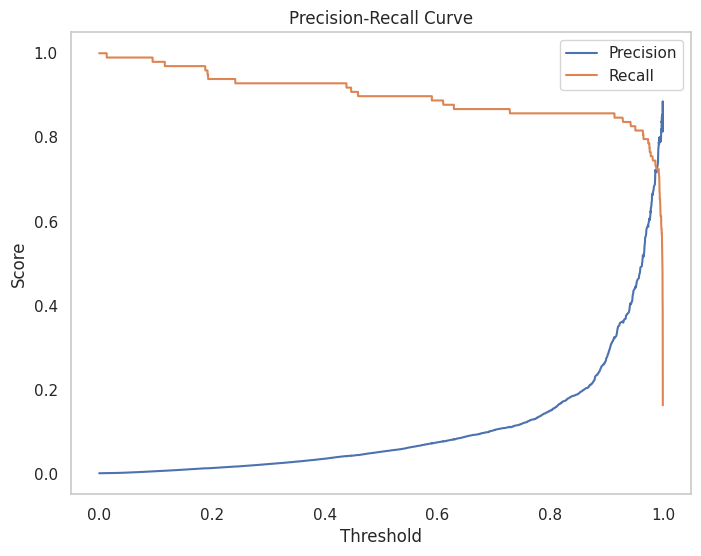

In [34]:
# Plot the precision-recall curve to visualize the trade-off
precision, recall, thresholds = precision_recall_curve(y_val, y_val_proba)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()

### Threshold Selection Rationale

After evaluating the model's performance at various thresholds, we selected **Threshold = 0.95** for the following reasons:

1. **Balanced Trade-Off**:
    - Precision: 0.44
    - Recall: 0.83
    - F1-Score: 0.58
    - This threshold provides a strong balance between precision and recall, ensuring that most fraudulent transactions are identified while minimizing false positives.
2. **Business Alignment**: The selected threshold aligns with general business requirement to reduce false positives (customer inconvenience) while maintaining high recall to catch fraudulent transactions.
3. **Performance Metrics**:
    - Macro Average:
        - Precision: 0.72
        - Recall: 0.91
        - F1-Score: 0.79
    - Weighted Average:
        - Precision: 1.00
        - Recall: 1.00
        - F1-Score: 1.00
    - These metrics indicate strong overall performance across both classes.

### Class Weights:

class_weight={0: 1, 1: 10} assigns a higher weight to the minority class (Class 1). This makes the model more sensitive to fraudulent transactions.

In [42]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = []
for w in range(40, 61, 1):
    # Assign higher weight to the minority class (fraudulent transactions)
    class_weights = {0: 1, 1: w}
    weighted_model = LogisticRegression(random_state=42, max_iter=2000, class_weight=class_weights)
    
    # Train the model on the original training set
    weighted_model.fit(X_train, y_train)
    
    # Evaluate the model on the validation set
    y_val_proba_weighted = weighted_model.predict_proba(X_val)[:, 1]
    y_val_adjusted_weighted = (y_val_proba_weighted >= 0.95).astype(int)
    
    # Store results
    results.append({
        "class_weight": w,
        "precision": precision_score(y_val, y_val_adjusted_weighted),
        "recall": recall_score(y_val, y_val_adjusted_weighted),
        "f1_score": f1_score(y_val, y_val_adjusted_weighted),
        "roc_auc": roc_auc_score(y_val, y_val_proba_weighted)
    })

# Print results
for result in results:
    print(result)

{'class_weight': 40, 'precision': 0.8846153846153846, 'recall': 0.7040816326530612, 'f1_score': 0.7840909090909091, 'roc_auc': np.float64(0.9791442877205401)}
{'class_weight': 41, 'precision': 0.8846153846153846, 'recall': 0.7040816326530612, 'f1_score': 0.7840909090909091, 'roc_auc': np.float64(0.9791520040828529)}
{'class_weight': 42, 'precision': 0.8846153846153846, 'recall': 0.7040816326530612, 'f1_score': 0.7840909090909091, 'roc_auc': np.float64(0.9791539780360027)}
{'class_weight': 43, 'precision': 0.8846153846153846, 'recall': 0.7040816326530612, 'f1_score': 0.7840909090909091, 'roc_auc': np.float64(0.9791432110188218)}
{'class_weight': 44, 'precision': 0.8734177215189873, 'recall': 0.7040816326530612, 'f1_score': 0.7796610169491526, 'roc_auc': np.float64(0.9791317262004955)}
{'class_weight': 45, 'precision': 0.8846153846153846, 'recall': 0.7040816326530612, 'f1_score': 0.7840909090909091, 'roc_auc': np.float64(0.9791564903400116)}
{'class_weight': 46, 'precision': 0.8734177215

In [43]:
# Fine-tune the threshold for class_weight=50
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve
import numpy as np

# Train the model with class_weight=50
class_weights = {0: 1, 1: 50}
weighted_model = LogisticRegression(random_state=42, max_iter=2000, class_weight=class_weights)
weighted_model.fit(X_train, y_train)

# Get predicted probabilities for the validation set
y_val_proba_weighted = weighted_model.predict_proba(X_val)[:, 1]

# Define thresholds to test
thresholds = np.arange(0.90, 1.00, 0.01)

# Evaluate the model at each threshold
results = []
for threshold in thresholds:
    y_val_adjusted = (y_val_proba_weighted >= threshold).astype(int)
    precision = precision_score(y_val, y_val_adjusted)
    recall = recall_score(y_val, y_val_adjusted)
    f1 = f1_score(y_val, y_val_adjusted)
    roc_auc = roc_auc_score(y_val, y_val_proba_weighted)
    results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": roc_auc
    })

# Print results
for result in results:
    print(f"Threshold: {result['threshold']:.2f}, Precision: {result['precision']:.2f}, Recall: {result['recall']:.2f}, F1-Score: {result['f1_score']:.2f}, ROC AUC: {result['roc_auc']:.2f}")

Threshold: 0.90, Precision: 0.80, Recall: 0.76, F1-Score: 0.78, ROC AUC: 0.98
Threshold: 0.91, Precision: 0.83, Recall: 0.76, F1-Score: 0.79, ROC AUC: 0.98
Threshold: 0.92, Precision: 0.84, Recall: 0.76, F1-Score: 0.80, ROC AUC: 0.98
Threshold: 0.93, Precision: 0.85, Recall: 0.74, F1-Score: 0.79, ROC AUC: 0.98
Threshold: 0.94, Precision: 0.88, Recall: 0.71, F1-Score: 0.79, ROC AUC: 0.98
Threshold: 0.95, Precision: 0.88, Recall: 0.71, F1-Score: 0.79, ROC AUC: 0.98
Threshold: 0.96, Precision: 0.88, Recall: 0.69, F1-Score: 0.78, ROC AUC: 0.98
Threshold: 0.97, Precision: 0.89, Recall: 0.66, F1-Score: 0.76, ROC AUC: 0.98
Threshold: 0.98, Precision: 0.88, Recall: 0.58, F1-Score: 0.70, ROC AUC: 0.98
Threshold: 0.99, Precision: 0.87, Recall: 0.55, F1-Score: 0.68, ROC AUC: 0.98


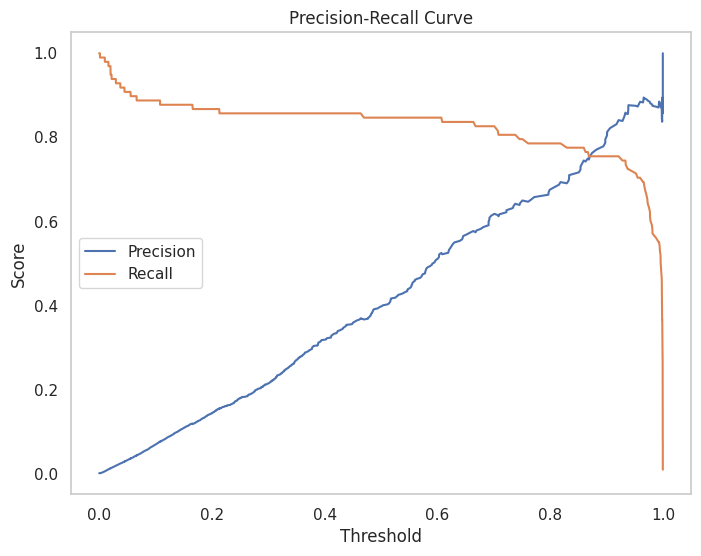

In [44]:
# Plot Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_val, y_val_proba_weighted)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()

### Decision on Class Weight and Threshold

After evaluation, the following configuration was selected as the optimal setup for the baseline model:
- **Class Weight**: 50
- **Threshold**: 0.92

#### Rationale
1. **Class Weight = 50**:
   - Assigning a higher weight to the minority class (fraudulent transactions) during training improved the model's sensitivity to fraud detection.
   - This resulted in a significant improvement in recall while maintaining high precision.

2. **Threshold = 0.92**:
   - Fine-tuning the threshold after training allowed for further optimization of the trade-off between precision and recall.
   - This threshold provided the highest F1-score (0.80), indicating the best balance between precision and recall.

#### Performance Metrics
- **Validation Set**:
  - Precision: 0.84
  - Recall: 0.76
  - F1-Score: 0.80
  - ROC AUC: 0.98

#### Trade-Offs
- The selected configuration prioritizes a balance between precision and recall, ensuring that most fraudulent transactions are identified while minimizing false positives.
- This balance aligns with the business requirement to reduce financial losses from missed fraud while minimizing customer inconvenience.

In [45]:
# Evaluate the model on the test set
y_test_proba = weighted_model.predict_proba(X_test)[:, 1]
y_test_adjusted = (y_test_proba >= 0.92).astype(int)

# Print performance metrics
print("Test Set Performance (Class Weight = 50, Threshold = 0.92):")
print(classification_report(y_test, y_test_adjusted))
print("ROC AUC Score (Test Set):", roc_auc_score(y_test, y_test_proba))

Test Set Performance (Class Weight = 50, Threshold = 0.92):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56869
           1       0.72      0.82      0.76        93

    accuracy                           1.00     56962
   macro avg       0.86      0.91      0.88     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC Score (Test Set): 0.9819158046118821


### Evaluation of Test Set Performance:
**Key Metrics:**

1. Class 0 (Non-Fraudulent Transactions):
- Precision, Recall, F1-Score: All are 1.00, indicating perfect classification for the majority class.
- This is expected due to the class imbalance, as the model is highly confident in identifying non-fraudulent transactions.

2. Class 1 (Fraudulent Transactions):
- Precision: 0.72
    - 72% of the transactions predicted as fraudulent are actually fraudulent.
- Recall: 0.82
    - 82% of the actual fraudulent transactions are correctly identified.
- F1-Score: 0.76
    - This reflects a good balance between precision and recall for the minority class.

3. Overall Accuracy:
- The accuracy is 1.00, but this is heavily influenced by the majority class (Class 0). Accuracy is not a reliable metric for imbalanced datasets.

4. Macro Average:
- Precision: 0.86, Recall: 0.91, F1-Score: 0.88
- These metrics average the scores for both classes equally, regardless of class imbalance.

5. Weighted Average:
- Precision, Recall, F1-Score: All are 1.00, reflecting the dominance of Class 0 in the dataset.

6. ROC AUC Score:
- The ROC AUC score of 0.982 indicates excellent discrimination between the classes.

#### Comparison with Validation Set:
- Validation Set:
    - Precision: 0.84, Recall: 0.76, F1-Score: 0.80, ROC AUC: 0.98
- Test Set:
    - Precision: 0.72, Recall: 0.82, F1-Score: 0.76, ROC AUC: 0.98
- Observations:
    - The test set results are consistent with the validation set, with a slight drop in precision but an improvement in recall.
    - The F1-score is slightly lower on the test set, but the ROC AUC score remains excellent, indicating strong generalization.

In [46]:
# Save the trained model to a file
import joblib

# Define the file path for saving the model
model_file_path = "../service/baseline_model.pkl"

# Save the model using joblib
joblib.dump(baseline_model, model_file_path)
print(f"Model saved to {model_file_path}")

Model saved to ../service/baseline_model.pkl
